# Homework 10

In [4]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
SHA256 hash of downloaded file: a876cc7106e7dcb1344fbec5dcd7510e5cd947e62049a8cbc188ad05ffe00345
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


/home/ese2131/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


### 1.1) Open the dataset and display its contents

In [7]:
# 1.1 Open the dataset
path = pooch.retrieve(url, known_hash=None)
ds = xr.open_dataset(path)
display(ds)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2) Print out the long_name attribute of each variable

In [8]:
for var in ds.variables:
    long_name = ds[var].attrs.get('long_name', 'N/A')
    print(f"{var:<20}: {long_name}")

lon                 : longitude
toa_sw_all_mon      : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon      : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon     : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon      : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon      : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon     : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon      : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon      : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon     : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon           : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon: Cloud Area Fraction, Monthly Means, Dayt

### 2.1) Calculate the time-mean of the entire dataset

In [11]:
ds_mean = ds.mean(dim='time')
print(ds_mean)

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 5

### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation

Text(0.5, 1.0, 'Incoming Solar')

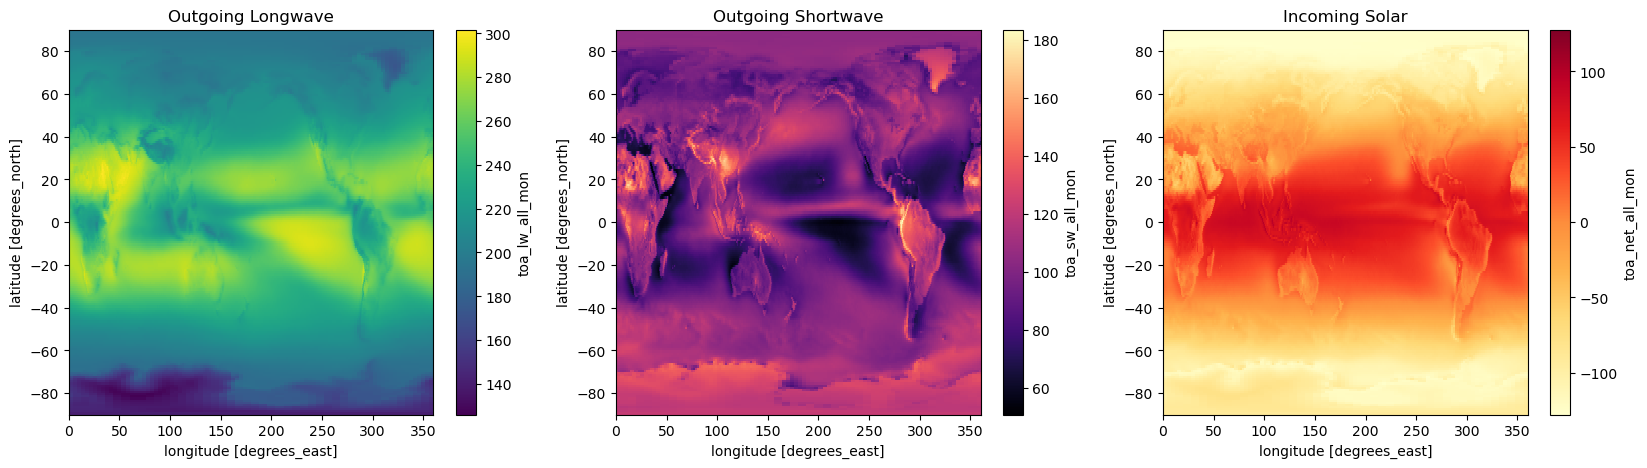

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ds_mean.toa_lw_all_mon.plot(ax=axes[0], cmap='viridis')
axes[0].set_title('Outgoing Longwave')

ds_mean.toa_sw_all_mon.plot(ax=axes[1], cmap='magma')
axes[1].set_title('Outgoing Shortwave')

ds_mean.toa_net_all_mon.plot(ax=axes[2], cmap='YlOrRd')
axes[2].set_title('Incoming Solar')

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

Text(0.5, 1.0, 'Calculated Net TOA Flux')

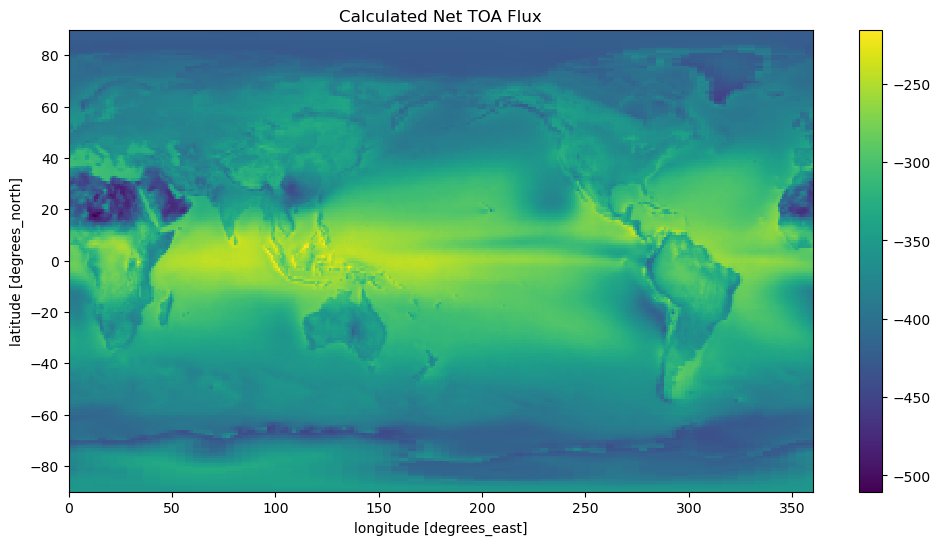

In [15]:
# Net = Incoming - Outgoing LW - Outgoing SW
net_flux_calc = ds_mean.toa_net_all_mon - ds_mean.toa_lw_all_mon - ds_mean.toa_sw_all_mon

plt.figure()
net_flux_calc.plot()
plt.title("Calculated Net TOA Flux")

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

In [16]:
print(f"Naive Mean Net Flux: {ds_mean.toa_net_all_mon.mean().values}")

Naive Mean Net Flux: -28.72901153564453


### 3.2) Create a weight array proportional to cos(lambda)

In [17]:
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor

In [18]:
ds_weighted = ds_mean.weighted(weights)
weighted_net = ds_weighted.mean(dim=('lat', 'lon'))
print(f"Weighted Mean Net Flux: {weighted_net.toa_net_all_mon.values}")

Weighted Mean Net Flux: 0.8780867457389832


### 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [21]:
sw_up = ds_weighted.mean(dim=('lat', 'lon')).toa_sw_all_mon
lw_up = ds_weighted.mean(dim=('lat', 'lon')).toa_lw_all_mon
solar_in = ds_weighted.mean(dim=('lat', 'lon')).toa_net_all_mon

print(f"Global Avg Solar In: {solar_in.values:.2f} W/m2")
print(f"Global Avg LW Out: {lw_up.values:.2f} W/m2")
print(f"Global Avg SW Out: {sw_up.values:.2f} W/m2")

Global Avg Solar In: 0.88 W/m2
Global Avg LW Out: 240.27 W/m2
Global Avg SW Out: 99.14 W/m2


### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [22]:
R = 6.371e6  # Earth radius in meters
dphi = np.deg2rad(1.0) # 1 degree spacing
dlambda = np.deg2rad(1.0)

# Create 2D latitude array
pixel_area = R**2 * np.cos(np.deg2rad(ds.lat)) * dphi * dlambda
pixel_area = xr.ones_like(ds_mean.toa_net_all_mon) * pixel_area

print(f"Total Area: {pixel_area.sum().values:.2e} m2")
print(f"Theoretical Area (4*pi*R^2): {4 * np.pi * R**2:.2e} m2")

Total Area: 5.10e+14 m2
Theoretical Area (4*pi*R^2): 5.10e+14 m2


### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band

Text(0, 0.5, 'Watts per latitude band')

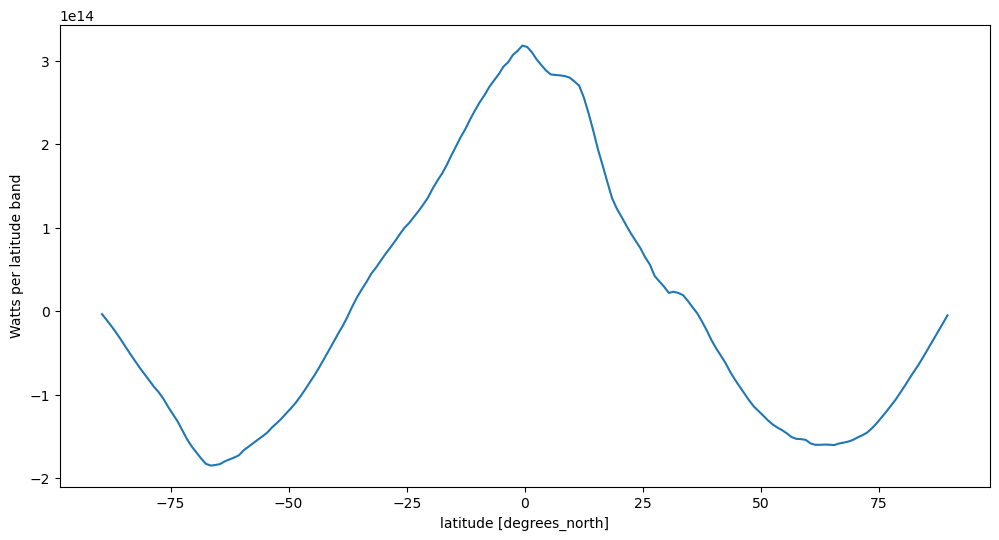

In [23]:
total_net_watts = (ds_mean.toa_net_all_mon * pixel_area).sum(dim='lon')
total_net_watts.plot()
plt.ylabel('Watts per latitude band')

### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

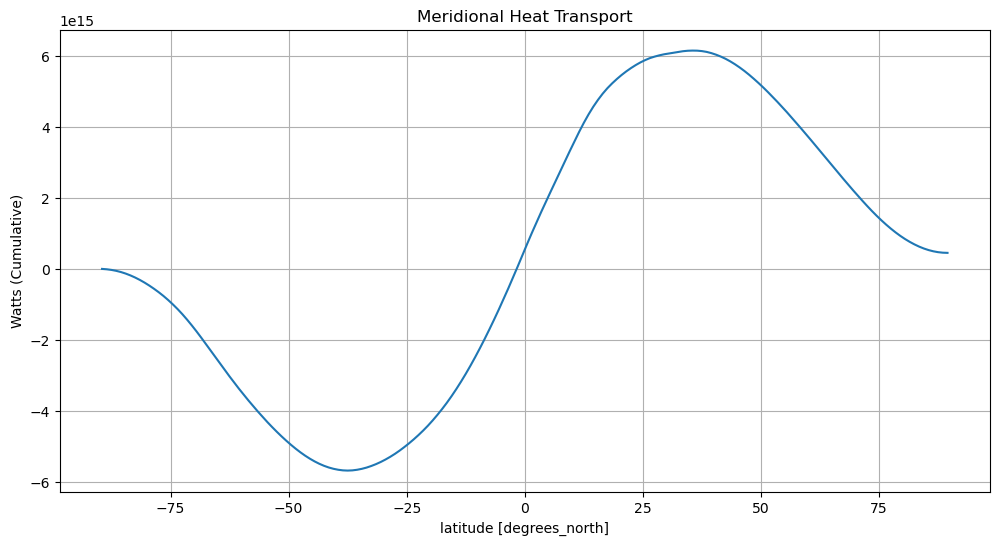

In [24]:
heat_transport = total_net_watts.cumsum(dim='lat')
heat_transport.plot()
plt.title('Meridional Heat Transport')
plt.ylabel('Watts (Cumulative)')
plt.grid(True)

### 5.2) Antarctic Sea Ice

In [34]:
import xarray as xr
import pooch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')
print(ds_ice)

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:             

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


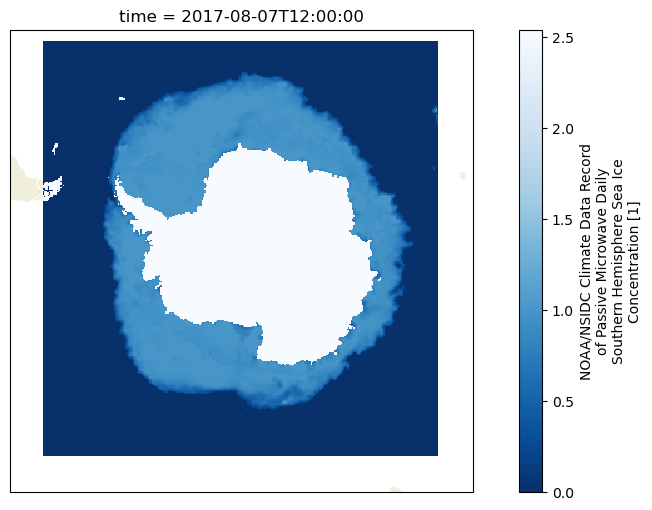

In [35]:
ax_ice = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ds_ice.seaice_conc_cdr.plot(ax=ax_ice, transform=ccrs.SouthPolarStereo(), cmap='Blues_r')
ax_ice.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
ax_ice.add_feature(cfeature.LAND)

### 5.3) Global USGS Earthquakes

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


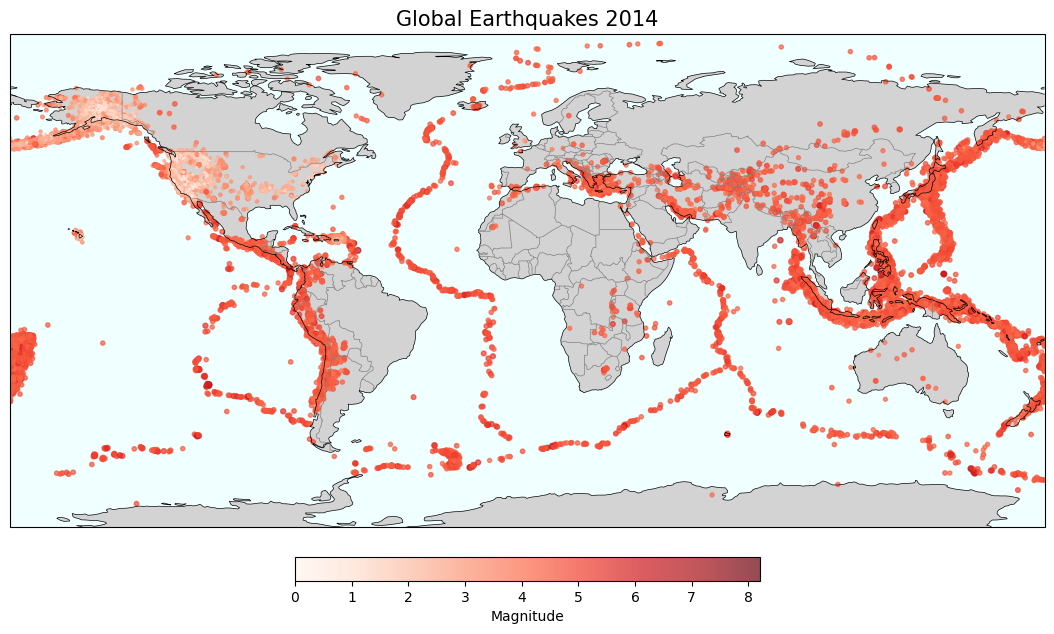

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load data
url_quakes = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(url_quakes)

# 2. Create the figure and axis with a projection
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree()) # Using PlateCarree for both map and data for simplicity

# 3. Add visible features so you can see the map is working
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='azure')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')

# 4. Plot the data
# Use scatter and explicitly define the transform
sc = ax.scatter(
    df['longitude'], 
    df['latitude'], 
    s=df['mag']**1.5, # Adjusted size for better visibility
    c=df['mag'], 
    cmap='Reds', 
    alpha=0.7, 
    transform=ccrs.PlateCarree()
)

# 5. Final touches
plt.colorbar(sc, label='Magnitude', orientation='horizontal', pad=0.05, shrink=0.4)
ax.set_title("Global Earthquakes 2014", fontsize=15)

plt.show()